# LQR Optimal Control Compared with Gradient Descent

## Imports

In [1]:
from typing import Any, Tuple, NamedTuple, Callable
from functools import partial
import time
import jax
from jax import Array
import jax.random as jr
import jax.numpy as jnp
from jax import value_and_grad, jit
from optax import adam, apply_updates
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from diffilqrax.utils import keygen
from diffilqrax.lqr import solve_lqr
from diffilqrax.typs import (
    LQR,
    LQRParams,
    ModelDims
)

PLOT_URL = (
    "https://gist.githubusercontent.com/"
    "ThomasMullen/e4a6a0abd54ba430adc4ffb8b8675520/"
    "raw/1189fbee1d3335284ec5cd7b5d071c3da49ad0f4/"
    "figure_style.mplstyle"
)
plt.style.use(PLOT_URL)

jax.config.update('jax_enable_x64', True)

## The Problem

We have simple integrator dynamics, where we want to steer the state to rest with minimal input energy.

$$
J_{k}(x_{k}) = \frac{1}{2}Q_{N} ||x_{N}||^{2} +\frac{1}{2} \sum^{N-1}_{i=k} \left(||x_{i}||^{2} + ||u_{i}||^{2} \right)
$$

The dynamics of the integrator are defined as,

$$
\left(\begin{matrix} p_{k+1} \\ v_{k+1} \end{matrix}\right) = 
\left( \begin{matrix} 1 & \delta t \\ 0 & 1 \end{matrix} \right)
\left(\begin{matrix} p_{k+1} \\ v_{k+1} \end{matrix}\right) + 
\left(\begin{matrix} \delta t \\ 0 \end{matrix}\right) u_{k}
$$



In [2]:
# define system dimensions
sys_dims = ModelDims(n=2,m=1,horizon=100, dt=0.1)

## Setting up LQR parameters

The `LQRParams` class contains parameters that contain the quadratic costs ($Q$, $Q_f$ $R$, $S$) and linear costs ($q$,$q_f$, $r$), the dynamic matrix ($A$), the input matrix ($B$), the state bias ($a$), and the initial state of the system $x_{0}$.

As this problem solves for finite horizon, the parameters need to span along the length of the horizon, and
$Q$ and $R$ need to be semi-positive definite (i.e. the diagonal components >= 0). 

In [3]:
# Define time invariant LQR problem
A = jnp.array([[1., 1.*sys_dims.dt], [0., 1.]])
B = jnp.array([[0.5*sys_dims.dt**2], [sys_dims.dt]])
# B = jnp.array([[0.5*sys_dims.dt**2, 0],
#                [sys_dims.dt, 0]])
a = jnp.zeros(sys_dims.n)
Q = jnp.eye(sys_dims.n)
q = jnp.zeros(sys_dims.n)
R = jnp.eye(sys_dims.m)
r = jnp.zeros(sys_dims.m)
S = jnp.zeros((sys_dims.n, sys_dims.m))
Qf = jnp.eye(sys_dims.n)
qf = jnp.zeros(sys_dims.n)

# Span along the horizon
span_mat = partial(jnp.tile, reps=(sys_dims.horizon,1,1))
span_vec = partial(jnp.tile, reps=(sys_dims.horizon,1))

# Define LQR problem through time
lqr_mats = LQR(
    A=span_mat(A),
    B=span_mat(B),
    a=span_vec(a),
    Q=span_mat(Q),
    q=span_vec(q),
    R=span_mat(R),
    r=span_vec(r),
    S=span_mat(S),
    Qf=Qf,
    qf=qf
)

In [4]:
# define an initial state of the system
key = jr.PRNGKey(seed=0)
k, sk = jr.split(key)
x0 = jr.normal(key, (sys_dims.n,))
# x0 = jnp.array([0., 0.])

print(f"Initial state:\n{x0}")

# Construct the LQR problem
lqr_params = LQRParams(
    x0=x0,
    lqr=lqr_mats
)

Initial state:
[ 1.81608667 -0.75488484]


## Solve LQR problem

In [5]:
lqr_st = time.time()
opt_traj = solve_lqr(lqr_params)
lqr_time = time.time()-lqr_st
opt_state, opt_input, opt_costate=opt_traj

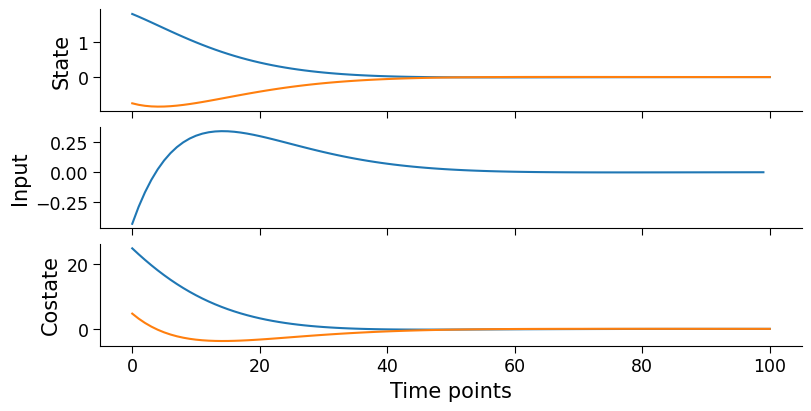

In [6]:
fig, axes = plt.subplots(3,1, figsize=(8,4), layout="constrained",sharex=True)
_ = [ax.plot(opt) for ax, opt in zip(axes.flatten(), opt_traj)]
_ = [ax.set_ylabel(n) for ax, n in zip(axes.flatten(), ["State", "Input", "Costate"])]
_ = axes[-1].set_xlabel("Time points")

## Solve LQR problem via back-propagation

### Define loss function

In [7]:
from diffilqrax.lqr import lin_dyn_step, simulate_trajectory

def cost_step(t, x, u, lqr_mats):
    return (
        0.5*x.T@lqr_mats.Q[t]@x +
        0.5*u.T@lqr_mats.R[t]@u +
        1.0*x.T@lqr_mats.S[t]@u +
        lqr_mats.r[t]@u +
        lqr_mats.q[t]@x
    )
def terminal_cost_step(x, lqr_mats):
    return (
        0.5*x.T@lqr_mats.Qf@x +
        lqr_mats.qf@x
    )

In [8]:
# Define loss function
def calc_total_cost(Us: Array, params: LQRParams) -> float:
    """Simulate forward cost."""
    x0, lqr_mats = params.x0, params.lqr
    tps = jnp.arange(100)

    def fwd_step(state, inputs):
        t, u = inputs
        x, nx_cost = state
        nx = lin_dyn_step(t, x, u, lqr_mats)
        nx_cost = nx_cost + cost_step(t, x, u, lqr_mats)
        return (nx, nx_cost), (nx)

    xf, nx_cost = jax.lax.scan(fwd_step, init=(x0, 0.0), xs=(tps, Us))[0]
    total_cost = nx_cost + terminal_cost_step(xf, lqr_mats)
    return total_cost

# Define gradient function
loss_and_grad_fn = jit( value_and_grad(calc_total_cost, argnums=(0,)) )

In [9]:
# initialise u0
u_init = jnp.zeros((sys_dims.horizon, sys_dims.m), dtype=jnp.float64)

In [10]:
# Define optimiser parameters and initialisation
lr=1e-3
solver = adam(learning_rate=lr)
opt_state_ = solver.init((u_init,))

u_updated = u_init

In [11]:
# iterations
losses = jnp.empty(1001//50)
bp_st = time.time()
for rep in range(1001):
    loss, grad = loss_and_grad_fn(u_updated, lqr_params)
    updates, opt_state_ = solver.update(grad, opt_state_, lqr_params)
    u_updated = apply_updates((u_updated,), updates)[0]

    if rep % 50 == 0:
        losses = losses.at[(rep//50)-1].set(loss)
    if rep % 200 == 0:
            print(f"Step {rep}, Loss: {loss:.4f}")
bp_time = time.time()-bp_st

Step 0, Loss: 467.0579
Step 200, Loss: 28.4852
Step 400, Loss: 24.1765
Step 600, Loss: 22.8896
Step 800, Loss: 22.3434
Step 1000, Loss: 22.1113


In [12]:

print(f"Clock time","==========",sep="\n")
print(f"LQR:\t\t{lqr_time:.3f}")
print(f"GD:\t\t{bp_time:.3f}")
print("",f"Final Loss","==========",sep="\n")
print(f"LQR cost:\t\t{calc_total_cost(opt_input, lqr_params):.3f}")
print(f"GD cost:\t\t{calc_total_cost(u_updated, lqr_params):.3f}")

Clock time
LQR:		1.018
GD:		2.586

Final Loss
LQR cost:		20.773
GD cost:		22.111


In [13]:
# view the results
x_updated = simulate_trajectory(lin_dyn_step, u_updated, lqr_params, sys_dims)

## Compare trajectories

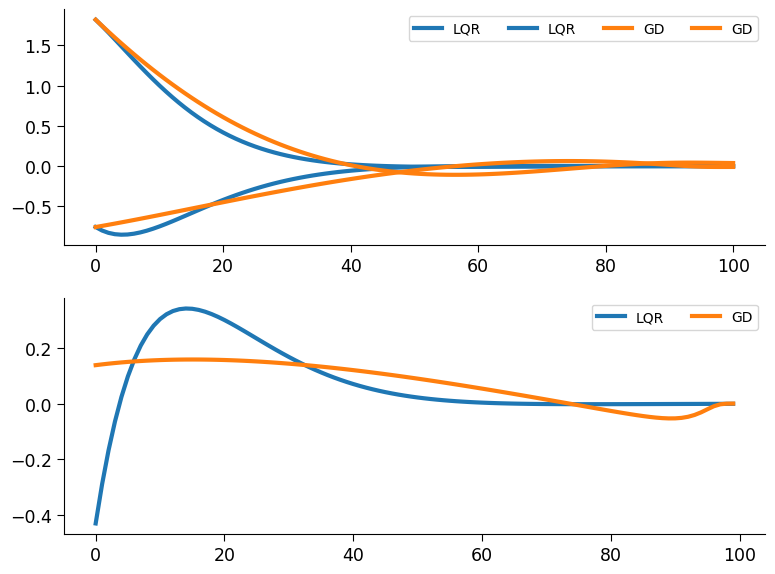

In [14]:
fig, axes = plt.subplots(2,1)
_ = axes[0].plot(opt_state,c="C0", label="LQR",lw=3)
_ = axes[0].plot(x_updated,c="C1", label="GD",lw=3)
_ = axes[0].legend(ncol=4, loc='upper right', prop={'size': 10})
_ = axes[1].plot(opt_input,c="C0", label="LQR",lw=3)
_ = axes[1].plot(u_updated,c="C1", label="GD",lw=3)
_ = axes[1].legend(ncol=2, loc='upper right', prop={'size': 10})